# FinTrustX: Production Preprocessing Pipeline

**Home Credit Default Risk | 02_Preprocessing**  
**Author:** FinTrustX Data Science Team | **Date:** August 2026 | **Python:** 3.12

This notebook builds, verifies, and persists the reusable preprocessing pipeline that converts raw application data into model-ready features.

## Objectives

- Split the data without leaking target information.
- Profile missingness and select defensible imputation strategies.
- Detect feature types and cardinality automatically.
- Reuse the project's `DataPreprocessor` framework for imputation, scaling, and encoding.
- Save the fitted pipeline, feature names, and processed train/test datasets for reproducible modelling.

# 3 Import Libraries

Production preprocessing must be reproducible. These imports provide data manipulation, visual quality checks, stratified splitting, persistence, and access to the project’s reusable preprocessing class. Version reporting helps reproduce results across development and deployment environments.

In [2]:

from __future__ import annotations

import os
import sys

def find_project_root(anchor_dirs=('src', 'data', 'models'), max_upward=4) -> Path:
    current = Path.cwd().resolve()
    if (current / 'Credit-risk-ai' / 'src').is_dir():
        return (current / 'Credit-risk-ai').resolve()
    for _ in range(max_upward):
        if all((current / marker).exists() for marker in anchor_dirs):
            return current
        if current.parent == current:
            break
        current = current.parent
    if (Path.cwd() / 'src').exists():
        return Path.cwd().resolve()
    if (Path.cwd().parent / 'src').exists():
        return Path.cwd().parent.resolve()
    return Path.cwd().resolve()

PROJECT_ROOT = find_project_root()
project_root = str(PROJECT_ROOT)
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import platform
import warnings
from pathlib import Path
from typing import Any
import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from src.config import MODEL_DIR, RANDOM_STATE
from src.preprocessing import DataPreprocessor

warnings.filterwarnings("ignore")
TARGET = "TARGET"
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR, REPORT_DIR = PROJECT_ROOT / "data", PROJECT_ROOT / "reports"
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})
display(pd.Series({"Python": platform.python_version(), "NumPy": np.__version__, "Pandas": pd.__version__, "scikit-learn": sklearn.__version__, "joblib": joblib.__version__, "Matplotlib": matplotlib.__version__, "Seaborn": sns.__version__}, name="Version").to_frame())
import platform
import warnings
from pathlib import Path
from typing import Any
import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from src.config import MODEL_DIR, RANDOM_STATE
from src.preprocessing import DataPreprocessor

warnings.filterwarnings("ignore")
TARGET = "TARGET"
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR, REPORT_DIR = PROJECT_ROOT / "data", PROJECT_ROOT / "reports"
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})
display(pd.Series({"Python": platform.python_version(), "NumPy": np.__version__, "Pandas": pd.__version__, "scikit-learn": sklearn.__version__, "joblib": joblib.__version__, "Matplotlib": matplotlib.__version__, "Seaborn": sns.__version__}, name="Version").to_frame())


,Version
Python,3.13.2
NumPy,2.4.6
Pandas,3.0.5
scikit-learn,1.9.0
joblib,1.5.3
Matplotlib,3.11.1
Seaborn,0.13.2


,Version
Python,3.13.2
NumPy,2.4.6
Pandas,3.0.5
scikit-learn,1.9.0
joblib,1.5.3
Matplotlib,3.11.1
Seaborn,0.13.2


# 4 Load Dataset

The raw training data is loaded once and the target is separated immediately. Separating `TARGET` prevents accidental target leakage into transformations. In business terms, this preserves the integrity of a risk score: the model must use only information that would be available when an applicant is assessed.

In [3]:
def find_train_file(data_dir: Path) -> Path:
    """Locate the Home Credit training file in project data folders."""
    candidates = [data_dir / "train.csv", data_dir / "raw" / "train.csv", data_dir / "application_train.csv", data_dir / "raw" / "application_train.csv"]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError("Place train.csv or application_train.csv in data/ or data/raw/.")

train_path = find_train_file(DATA_DIR)
raw_data = pd.read_csv(train_path)
if TARGET not in raw_data:
    raise KeyError(f"Expected target column {TARGET!r} was not found.")
X, y = raw_data.drop(columns=TARGET), raw_data[TARGET]
print(f"Dataset: {train_path}\nFeatures: {X.shape}\nTarget: {y.shape}")
display(y.value_counts(normalize=True).rename("proportion").to_frame())

Dataset: d:\Projects\Credit-risk-ai\data\raw\application_train.csv
Features: (307511, 121)
Target: (307511,)


,proportion
TARGET,
0,0.919271
1,0.080729


# 5 Train Test Split

A stratified split preserves the default-rate distribution in both datasets. This is important because defaults are relatively rare: without stratification, an unrepresentative test set could overstate model quality or hide failure to identify risky applicants. The test set remains untouched while the pipeline learns all imputation, scaling, and category vocabulary from training data only.

,train,test
rows,246008.000000,61503.000000
default_rate,0.080729,0.080728


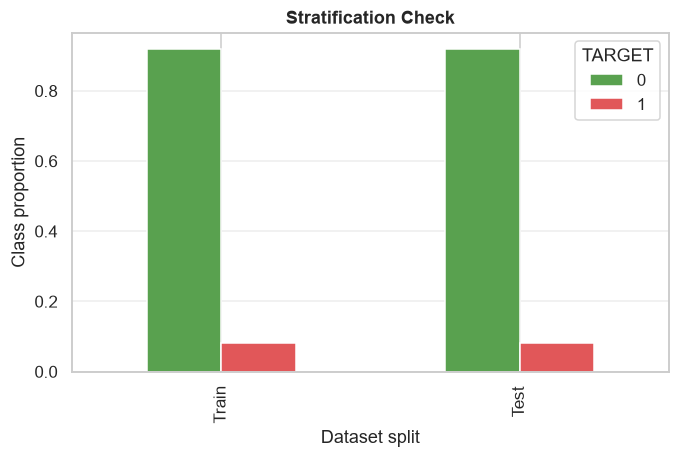

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
split_summary = pd.DataFrame({"train": [len(X_train), y_train.mean()], "test": [len(X_test), y_test.mean()]}, index=["rows", "default_rate"])
display(split_summary)
fig, ax = plt.subplots(figsize=(7, 4))
pd.DataFrame({"Train": y_train.value_counts(normalize=True), "Test": y_test.value_counts(normalize=True)}).T.plot(kind="bar", ax=ax, color=["#59A14F", "#E15759"])
ax.set(title="Stratification Check", xlabel="Dataset split", ylabel="Class proportion"); ax.grid(axis="y", alpha=.35); plt.show()

# 6 Missing Value Analysis

Imputation strategy depends on feature meaning and type. Features that are almost entirely missing provide little stable evidence and are candidates for dropping. Numerical fields use a robust median by default; mean imputation is reserved for approximately symmetric distributions; categorical fields use their most frequent category; explicit constant values can preserve an “unknown” state where it is business meaningful. All choices are fitted using training data only to avoid leakage.

In [5]:
def build_missing_strategy_summary(frame: pd.DataFrame, threshold: float = 0.95) -> pd.DataFrame:
    """Recommend an imputation action for every feature from type and missingness."""
    rows: list[dict[str, Any]] = []
    for column in frame.columns:
        missing_pct = frame[column].isna().mean() * 100
        if missing_pct >= threshold * 100:
            action, rationale = "Drop", f"Missing in at least {threshold:.0%} of training records"
        elif pd.api.types.is_numeric_dtype(frame[column]):
            skew = frame[column].dropna().skew()
            action = "Mean imputation" if abs(skew) < .5 else "Median imputation"
            rationale = "Approximately symmetric" if action.startswith("Mean") else "Robust to skew and outliers"
        elif pd.api.types.is_bool_dtype(frame[column]):
            action, rationale = "Constant value", "Preserve explicit unknown boolean state"
        else:
            action, rationale = "Most frequent", "Stable category baseline; encoder ignores unseen categories"
        rows.append({"feature": column, "dtype": str(frame[column].dtype), "missing_pct": missing_pct, "recommended_action": action, "rationale": rationale})
    return pd.DataFrame(rows).sort_values("missing_pct", ascending=False)

missing_strategy = build_missing_strategy_summary(X_train)
display(missing_strategy)
drop_columns = missing_strategy.query("recommended_action == 'Drop'")["feature"].tolist()
print(f"Columns dropped for ≥95% missingness: {len(drop_columns)}")

,feature,dtype,missing_pct,recommended_action,rationale
47,COMMONAREA_AVG,float64,69.839599,Median imputation,Robust to skew and outliers
75,COMMONAREA_MEDI,float64,69.839599,Median imputation,Robust to skew and outliers
61,COMMONAREA_MODE,float64,69.839599,Median imputation,Robust to skew and outliers
55,NONLIVINGAPARTMENTS_AVG,float64,69.399776,Median imputation,Robust to skew and outliers
83,NONLIVINGAPARTMENTS_MEDI,float64,69.399776,Median imputation,Robust to skew and outliers
...,...,...,...,...,...
109,FLAG_DOCUMENT_16,int64,0.000000,Median imputation,Robust to skew and outliers
108,FLAG_DOCUMENT_15,int64,0.000000,Median imputation,Robust to skew and outliers
107,FLAG_DOCUMENT_14,int64,0.000000,Median imputation,Robust to skew and outliers
113,FLAG_DOCUMENT_20,int64,0.000000,Median imputation,Robust to skew and outliers


Columns dropped for ≥95% missingness: 0


# 7 Feature Type Detection

Automatic type detection prevents brittle, hand-maintained feature lists. Cardinality highlights categorical columns with many distinct values, which can produce very wide sparse matrices after encoding. The project framework detects numerical and categorical columns; this notebook adds boolean and cardinality reporting, then normalises booleans into categorical inputs for the reusable pipeline.

In [6]:
def detect_feature_types(frame: pd.DataFrame, high_cardinality_threshold: int = 25) -> dict[str, list[str]]:
    """Detect preprocessing groups after dropping unusably incomplete fields."""
    return {
        "numerical": frame.select_dtypes(include=np.number).columns.tolist(),
        "categorical": frame.select_dtypes(include=["object", "string", "category"]).columns.tolist(),
        "boolean": frame.select_dtypes(include=["bool"]).columns.tolist(),
        "high_cardinality": [c for c in frame.select_dtypes(include=["object", "string", "category"]).columns if frame[c].nunique(dropna=True) > high_cardinality_threshold],
        "low_cardinality": [c for c in frame.select_dtypes(include=["object", "string", "category"]).columns if frame[c].nunique(dropna=True) <= high_cardinality_threshold],
    }

X_train = X_train.drop(columns=drop_columns)
X_test = X_test.drop(columns=drop_columns)
feature_types = detect_feature_types(X_train)
display(pd.Series({name: len(columns) for name, columns in feature_types.items()}, name="Feature count").to_frame())
display(pd.DataFrame({"feature": feature_types["high_cardinality"], "unique_values": [X_train[c].nunique() for c in feature_types["high_cardinality"]]}).sort_values("unique_values", ascending=False))

,Feature count
numerical,105
categorical,16
boolean,0
high_cardinality,1
low_cardinality,15


,feature,unique_values
0,ORGANIZATION_TYPE,58


# 8 Categorical Encoding

Label encoding assigns arbitrary integers and can imply a false ranking. Ordinal encoding is appropriate only when order is real and documented. Target encoding can be compact for high-cardinality data but requires careful cross-fitting to prevent leakage. One-hot encoding is selected here because it makes no ordinal assumption, is transparent for explanations, and `handle_unknown='ignore'` makes the pipeline resilient to new categories at inference time.

In [7]:
encoding_comparison = pd.DataFrame({"Method": ["Label", "Ordinal", "One-hot", "Target"], "Strength": ["Compact", "Respects genuine order", "Transparent; no false order", "Compact for many categories"], "Primary risk": ["Artificial order", "Wrong order assumption", "Wide feature matrix", "Target leakage"], "Decision": ["Not selected", "Not selected", "Selected", "Not selected"]})
display(encoding_comparison)

,Method,Strength,Primary risk,Decision
0,Label,Compact,Artificial order,Not selected
1,Ordinal,Respects genuine order,Wrong order assumption,Not selected
2,One-hot,Transparent; no false order,Wide feature matrix,Selected
3,Target,Compact for many categories,Target leakage,Not selected


# 9 Numerical Scaling

StandardScaler centres features and scales them to unit variance. MinMaxScaler bounds values but is sensitive to outliers; RobustScaler is resilient to outliers but does not provide the common standardised scale expected by many baseline models. We select StandardScaler because it supports linear models, distance-sensitive methods, and neural networks consistently. Tree models are less sensitive to scaling, but a single standard pipeline improves interoperability.

In [8]:
scaler_comparison = pd.DataFrame({"Scaler": ["StandardScaler", "MinMaxScaler", "RobustScaler"], "Behaviour": ["Mean 0, variance 1", "Maps to a fixed range", "Uses median and IQR"], "Trade-off": ["Sensitive to extreme values", "Very sensitive to extremes", "Less intuitive model-space scale"], "Decision": ["Selected", "Not selected", "Consider after outlier validation"]})
display(scaler_comparison)

,Scaler,Behaviour,Trade-off,Decision
0,StandardScaler,"Mean 0, variance 1",Sensitive to extreme values,Selected
1,MinMaxScaler,Maps to a fixed range,Very sensitive to extremes,Not selected
2,RobustScaler,Uses median and IQR,Less intuitive model-space scale,Consider after outlier validation


# 10 Build Preprocessing Pipeline

The notebook reuses `src.preprocessing.DataPreprocessor`, the project’s common `ColumnTransformer` pipeline. Its numerical branch applies `SimpleImputer(strategy='median')` followed by `StandardScaler`; its categorical branch applies most-frequent imputation followed by `OneHotEncoder(handle_unknown='ignore')`. A boolean value is categorical in this context, so it is converted to a string category before fitting. This centralisation ensures model notebooks and inference use the same transformation contract.

In [9]:
def prepare_boolean_features(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Convert booleans to stable categorical strings without mutating caller data."""
    prepared = frame.copy()
    for column in columns:
        prepared[column] = prepared[column].astype("object").where(prepared[column].notna(), np.nan)
    return prepared

X_train_ready = prepare_boolean_features(X_train, feature_types["boolean"])
X_test_ready = prepare_boolean_features(X_test, feature_types["boolean"])
preprocessor = DataPreprocessor()
numeric_features, categorical_features = preprocessor.detect_features(pd.concat([X_train_ready, y_train], axis=1), target_column=TARGET)
pipeline = preprocessor.build_pipeline()
preprocessor.summary()

Feature Detection
Numerical : 105
Categorical : 16
Preprocessing Pipeline
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['SK_ID_CURR', 'CNT_CHILDREN',
                                  'AMT_INCOME_TOTAL', 'AMT_CREDIT',
                                  'AMT_ANNUITY', 'AMT_GOODS_PRICE',
                                  'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH',
                                  'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
                                  'DAYS_ID_PUBLISH', 'OWN_CAR_AGE',
                                  'FLAG_MOBIL', 'FLA...
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
       

# 11 Fit Pipeline

Fitting occurs exclusively on the training features. This is a critical anti-leakage control: test-set medians, category frequencies, and scaling parameters must not influence how the model learns. The same fitted transformer then maps the test set into exactly the same feature space, producing an honest estimate of production performance.

In [10]:
X_train_processed = preprocessor.fit_transform(X_train_ready)
X_test_processed = preprocessor.transform(X_test_ready)
print(f"Processed train shape: {X_train_processed.shape}")
print(f"Processed test shape:  {X_test_processed.shape}")

Processed train shape: (246008, 245)
Processed test shape:  (61503, 245)


# 12 Save Pipeline

Persisting the fitted pipeline ensures that APIs and future notebooks apply exactly the transformations learned during training. Without this artifact, production could encode categories or scale amounts differently from the model-development environment, creating unreliable loan-risk outputs.

In [11]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)
pipeline_path = MODEL_DIR / "preprocessing_pipeline.joblib"
preprocessor.save_pipeline(filename=pipeline_path.name)
print(f"Saved pipeline: {pipeline_path}")

Pipeline saved to D:\Projects\Credit-risk-ai\models\preprocessing_pipeline.joblib
Saved pipeline: D:\Projects\Credit-risk-ai\models\preprocessing_pipeline.joblib


# 13 Save Feature Names

Transformed feature names link model inputs back to business variables. They are essential for feature importance, SHAP explanations, monitoring, and audit conversations. Saving this mapping prevents opaque column indices from reaching later modelling stages.

In [12]:
feature_names = preprocessor.get_feature_names()
feature_names_path = MODEL_DIR / "preprocessed_feature_names.csv"
pd.DataFrame({"feature_name": feature_names}).to_csv(feature_names_path, index=False)
print(f"Saved {len(feature_names):,} feature names to {feature_names_path}")
display(pd.DataFrame({"feature_name": feature_names}).head())

Saved 245 feature names to D:\Projects\Credit-risk-ai\models\preprocessed_feature_names.csv


,feature_name
0,num__SK_ID_CURR
1,num__CNT_CHILDREN
2,num__AMT_INCOME_TOTAL
3,num__AMT_CREDIT
4,num__AMT_ANNUITY


# 14 Save Processed Dataset

The processed arrays and aligned targets are saved as portable data frames for the model-training notebook. This makes experimentation faster while preserving a clear boundary: preprocessing is fit only on training data, and the test representation uses the frozen transformer.

In [14]:
def save_processed_split(features: np.ndarray, target: pd.Series, names: np.ndarray, path: Path) -> None:
    """Save transformed features with an aligned target column.

    Accept sparse matrices or array-likes and convert to a numpy ndarray.
    """
    if not isinstance(features, np.ndarray):
        toarray = getattr(features, "toarray", None)
        if callable(toarray):
            features = toarray()
        else:
            features = np.asarray(features)

    output = pd.DataFrame(features, columns=names, index=target.index)
    output[TARGET] = target
    output.to_parquet(path, index=True)

processed_train_path, processed_test_path = DATA_DIR / "processed_train.parquet", DATA_DIR / "processed_test.parquet"
save_processed_split(X_train_processed, y_train, feature_names, processed_train_path)
save_processed_split(X_test_processed, y_test, feature_names, processed_test_path)
print(f"Saved: {processed_train_path}\nSaved: {processed_test_path}")

Saved: d:\Projects\Credit-risk-ai\data\processed_train.parquet
Saved: d:\Projects\Credit-risk-ai\data\processed_test.parquet


# 15 Pipeline Verification

Reloading the artifact and transforming a small test sample verifies that the persisted object is usable independently of the current Python object. Matching dimensions and finite numerical outputs are basic release checks before model training or API integration.

In [15]:
loaded_pipeline = joblib.load(pipeline_path)
sample = X_test_ready.head(5)
sample_processed = loaded_pipeline.transform(sample)
assert sample_processed.shape[1] == X_train_processed.shape[1], "Feature dimensions do not match."
assert np.isfinite(sample_processed).all(), "Transformed sample contains non-finite values."
print(f"Verification passed. Sample input: {sample.shape}; transformed output: {sample_processed.shape}")

Verification passed. Sample input: (5, 121); transformed output: (5, 245)


# 16 Summary

The production preprocessing contract is: remove fields with at least 95% missingness; median-impute and standardise numerical features; most-frequent-impute and one-hot encode categorical or boolean features; ignore unseen categories safely; and preserve target stratification. The fitted pipeline, transformed feature names, and train/test datasets are persisted for reproducibility.

These choices reduce leakage, improve compatibility across model families, and provide a transparent foundation for explanations. The next notebook, **03_ML_Models.ipynb**, will train and evaluate candidate models using these frozen, model-ready datasets.